在封闭系统中优化 $$ \sqrt{X} $$ 门的脉冲并保存，后续传入开放系统做作为初始脉冲来优化

Final state2222: [-0.63804273+0.28554j    -0.21024364-0.67248987j -0.00159505-0.12182365j
  0.00075097-0.00890281j]
Final state2222: [-0.21024364-0.67248987j -0.64029847+0.11325534j -0.28326829+0.00812481j
 -0.02078604+0.00266259j]
Final state2222: [-0.59982905-0.27361487j -0.6014241 -0.39543853j -0.2014288 -0.08039722j
 -0.01416693-0.0044125j ]
Final state2222: [-0.30249964+0.67742942j  0.30409469-0.55560577j  0.19917306-0.09188744j
  0.01522897-0.00817797j]
Final state2222: [ 0.02435781+0.05324257j -0.22874833-0.92828154j -0.00687298-0.28644326j
 -0.00135172-0.02099318j]
Final state2222: [-0.92668649+0.35057198j -0.06858108-0.02276276j  0.00461724+0.1141586j
  0.00241375+0.00840271j]
GRAPE Optimization Tutorial: Transmon Qubit √X Gate (Fixed Version)
System: 4-level transmon
Anharmonicity: -200.0 MHz
Gate time: 15.0 ns
Time resolution: 0.5 ns
Initial Rabi frequency: 50.0 MHz
Initial fidelity: 0.317798

Starting GRAPE optimization...
(This may take 30-60 seconds)

Final state2222: [-0

/var/folders/g8/47vxxjf90dv9kp9zkqb3pdlm0000gn/T/ipykernel_57451/1268600222.py:309: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  result = minimize(


Final state2222: LinearizeTracer<complex128[4]>
Final state2222: LinearizeTracer<complex128[4]>
Final state2222: LinearizeTracer<complex128[4]>
Final state2222: LinearizeTracer<complex128[4]>
Final state2222: [-0.63804273+0.28554j    -0.21024389-0.67248979j -0.00159514-0.12182365j
  0.00075096-0.00890281j]
Final state2222: [-0.21024339-0.67248995j -0.64029847+0.11325534j -0.28326828+0.00812492j
 -0.02078604+0.0026626j ]
Final state2222: [-0.59982887-0.27361493j -0.60142427-0.39543847j -0.20142886-0.08039715j
 -0.01416694-0.00441249j]
Final state2222: [-0.30249981+0.67742947j  0.30409451-0.55560571j  0.19917299-0.09188751j
  0.01522896-0.00817798j]
Final state2222: [ 0.02435786+0.05324275j -0.2287485 -0.92828148j -0.00687312-0.28644325j
 -0.00135173-0.02099318j]
Final state2222: [-0.92668654+0.3505718j  -0.06858126-0.0227627j   0.00461725+0.11415859j
  0.00241375+0.00840271j]
Final state2222: [-0.63804273+0.28554j    -0.2102449 -0.67248948j -0.00159551-0.12182364j
  0.00075092-0.0089028

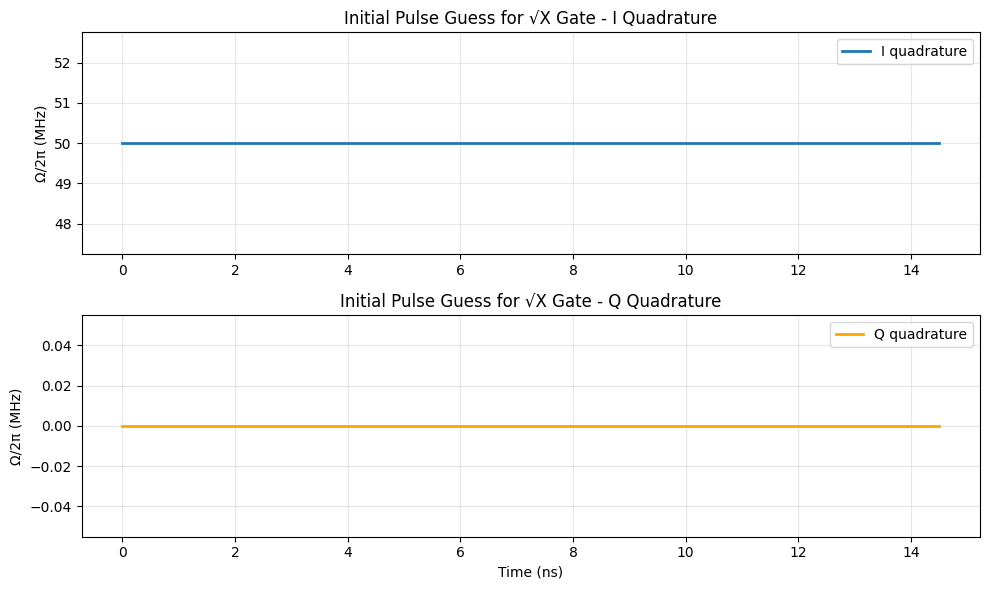

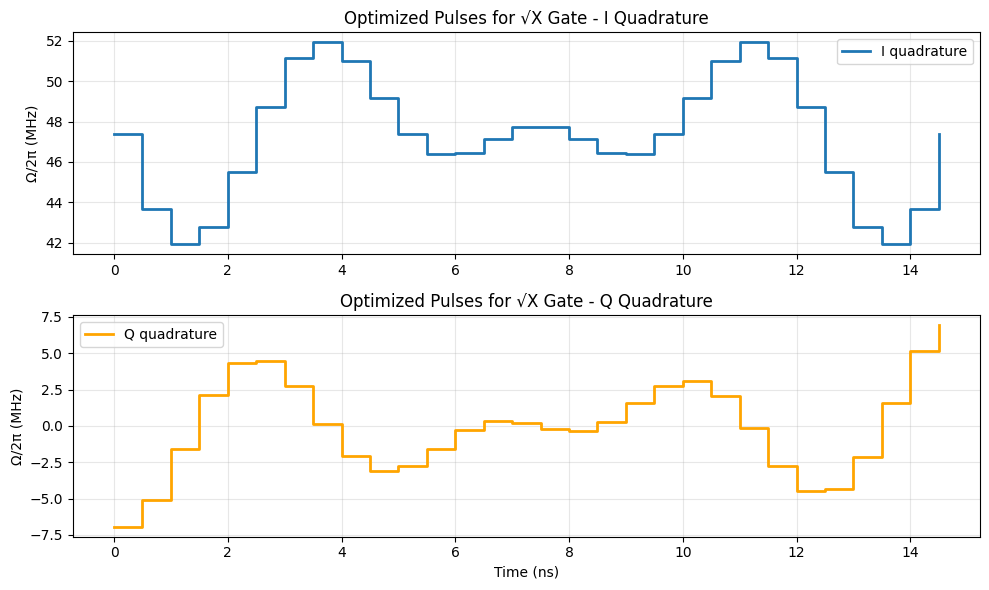

Final State: [-5.53093611e-01+0.23538043j  2.05184927e-01+0.76989637j
 -2.10334962e-02-0.05826194j -2.08209182e-04+0.00230778j]
Final state2222: [-5.53093611e-01+0.23538043j  2.05184927e-01+0.76989637j
 -2.10334962e-02-0.05826194j -2.08209182e-04+0.00230778j]
Fidelity: 0.972200
target_state : [0.5+0.5j 0.5-0.5j 0. +0.j  0. +0.j ]

Final State Analysis:
----------------------------------------
  |0⟩: 0.361316
  |1⟩: 0.634841
  |2⟩: 0.003837
  |3⟩: 0.000005

Leakage to |2⟩ and above: 0.003842

Optimized pulses saved to 'sqrtx_closed_system_pulses_fixed.npy'
  Shape: (30, 2)
  Format: [Ω_I(t), Ω_Q(t)] in rad/s

√X Gate Verification on All Cardinal States
Final state2222: [-5.53093611e-01+0.23538043j  2.05184927e-01+0.76989637j
 -2.10334962e-02-0.05826194j -2.08209182e-04+0.00230778j]
|0⟩: Fidelity = 0.972200
Final state2222: [ 0.20518493+0.76989637j -0.58757848+0.0724544j   0.12051788+0.00741784j
 -0.00685368+0.00583473j]
|1⟩: Fidelity = 0.959911
Final state2222: [-0.24600859+0.71083804j 

In [1]:
import jax
import jax.numpy as jnp
from jax import grad, jit
from scipy.optimize import minimize
import numpy as np
from functools import partial
import matplotlib.pyplot as plt

# Enable 64-bit precision for numerical accuracy
jax.config.update("jax_enable_x64", True)


class TransmonGRAPEFixed:
    """
    GRAPE (Gradient Ascent Pulse Engineering) optimization for transmon qubit 
    in the rotating frame.
    
    This class implements pulse optimization for a multilevel transmon system
    with comprehensive evaluation using 6 cardinal states and correct √X gate targets.
    """
    
    def __init__(self, n_levels, alpha, omega_d, omega_q, dt, n_steps):
        """
        Initialize the GRAPE optimizer for a transmon qubit.
        
        Parameters:
        -----------
        n_levels : int
            Number of transmon energy levels to include in simulation.
            Typical values: 3-5 (including ground state).
        alpha : float
            Anharmonicity in angular frequency units (rad/s).
            For transmons, typically negative: α ≈ -2π × (200 MHz).
        omega_d : float
            Drive frequency in rad/s.
        omega_q : float
            Qubit transition frequency (|0⟩ to |1⟩) in rad/s.
        dt : float
            Time step for pulse discretization in seconds.
            Should be much smaller than 1/Ω_Rabi for accuracy.
        n_steps : int
            Number of discrete time steps in the pulse sequence.
        """
        self.n_levels = n_levels
        self.alpha = alpha
        self.omega_d = omega_d
        self.omega_q = omega_q
        self.delta = omega_d - omega_q  # Detuning from qubit frequency
        self.dt = dt
        self.n_steps = n_steps
        
        # Create annihilation operator (truncated to n_levels)
        self.a = jnp.zeros((n_levels, n_levels), dtype=jnp.complex128)
        for i in range(n_levels - 1):
            self.a = self.a.at[i, i+1].set(jnp.sqrt(i+1))
        
        # Create number operator
        self.n_op = self.a.T.conj() @ self.a
        
        # Static Hamiltonian in rotating frame
        # H_static = α/2 * (a†a)(a†a - 1) - Δ a†a
        self.H_static = (alpha / 2) * self.n_op @ (self.n_op - jnp.eye(n_levels))
        self.H_static = self.H_static - self.delta * self.n_op
    
    def create_cardinal_states(self):
        """
        Create 6 cardinal states for comprehensive gate evaluation.
        
        Returns:
        --------
        cardinal_states : list of jnp.array
            List of 6 cardinal quantum states
        """
        ket0 = jnp.zeros(self.n_levels, dtype=jnp.complex128).at[0].set(1.0)
        ket1 = jnp.zeros(self.n_levels, dtype=jnp.complex128).at[1].set(1.0)
        
        cardinal_states = [
            ket0,  # |0⟩
            ket1,  # |1⟩
            (ket0 + ket1) / jnp.sqrt(2),  # |+⟩ = (|0⟩ + |1⟩)/√2
            (ket0 - ket1) / jnp.sqrt(2),  # |-⟩ = (|0⟩ - |1⟩)/√2
            (ket0 + 1j*ket1) / jnp.sqrt(2),  # |+i⟩ = (|0⟩ + i|1⟩)/√2
            (ket0 - 1j*ket1) / jnp.sqrt(2),  # |-i⟩ = (|0⟩ - i|1⟩)/√2
        ]
        
        return cardinal_states
    
    def sqrt_x_gate_target_for_state(self, initial_state):
        """
        Create target state for √X gate applied to a specific initial state.
        
        Parameters:
        -----------
        initial_state : jnp.array
            Initial quantum state
            
        Returns:
        --------
        target_state : jnp.array
            Target state after applying √X gate to the initial state
        """
        # √X gate matrix in computational basis
        sqrt_x_matrix = jnp.array([
            [1 + 1j, 1 - 1j],
            [1 - 1j, 1 + 1j]
        ], dtype=jnp.complex128) / 2
        
        # Apply √X gate to the first two levels (qubit subspace)
        qubit_state = initial_state[:2]
        target_qubit_state = sqrt_x_matrix @ qubit_state
        
        # Create target state in full Hilbert space
        target_state = jnp.zeros(self.n_levels, dtype=jnp.complex128)
        target_state = target_state.at[:2].set(target_qubit_state)
        
        return target_state
    
    def get_cardinal_target_states(self):
        """
        Get target states for all 6 cardinal states after √X gate.
        
        Returns:
        --------
        target_states : list of jnp.array
            Target states for each cardinal state after √X gate
        """
        cardinal_states = self.create_cardinal_states()
        target_states = []
        
        for state in cardinal_states:
            target_state = self.sqrt_x_gate_target_for_state(state)
            target_states.append(target_state)
        
        return target_states
    
    def forward_propagation(self, pulses, phi, initial_state):
        """
        Simulate quantum evolution for given pulse sequence.
        
        Parameters:
        -----------
        pulses : array of shape (n_steps, 2)
            Pulse amplitudes [omega_I, omega_Q] in rad/s
        phi : float
            Phase rotation parameter
        initial_state : array
            Initial quantum state
            
        Returns:
        --------
        final_state : array
            Final quantum state after evolution
        """
        # Apply phase rotation to pulses
        cos_phi = jnp.cos(phi)
        sin_phi = jnp.sin(phi)
        omega_I = pulses[:, 0]
        omega_Q = pulses[:, 1]
        omega_tilde_I = omega_I * cos_phi + omega_Q * sin_phi
        omega_tilde_Q = -omega_I * sin_phi + omega_Q * cos_phi
        
        # Initialize state
        state = initial_state
        
        # Time evolution using piecewise-constant approximation
        for step in range(self.n_steps):
            # Drive Hamiltonian for this time step
            H_drive = 0.5 * (omega_tilde_I[step] * (self.a + self.a.T.conj()) +
                            omega_tilde_Q[step] * (1j * (self.a - self.a.T.conj())))
            
            # Total Hamiltonian
            H_total = self.H_static + H_drive
            
            # Time evolution operator
            U = jax.scipy.linalg.expm(-1j * H_total * self.dt)
            
            # Evolve state
            state = U @ state
        
        return state
    
    def fidelity(self, pulses, phi, initial_state, target_state):
        """
        Compute quantum state fidelity.
        
        Parameters:
        -----------
        pulses : array of shape (n_steps, 2)
            Pulse amplitudes
        phi : float
            Phase parameter
        initial_state : array
            Initial quantum state
        target_state : array
            Target quantum state
            
        Returns:
        --------
        fidelity : float
            Quantum state fidelity |⟨target|final⟩|²
        """
        final_state = self.forward_propagation(pulses, phi, initial_state)
        print(f"Final state2222: {final_state}")
        overlap = jnp.vdot(target_state, final_state)
        return jnp.abs(overlap) ** 2
    
    def average_fidelity_cardinal_states(self, pulses, phi):
        """
        Compute average fidelity over all 6 cardinal states.
        
        Parameters:
        -----------
        pulses : array of shape (n_steps, 2)
            Pulse amplitudes
        phi : float
            Phase parameter
            
        Returns:
        --------
        avg_fidelity : float
            Average fidelity over 6 cardinal states
        """
        cardinal_states = self.create_cardinal_states()
        
        fidelities = []
        for initial_state in cardinal_states:
            # Calculate the correct target state for each initial state after √X gate
            target_state = self.sqrt_x_gate_target_for_state(initial_state)
            fid = self.fidelity(pulses, phi, initial_state, target_state)
            fidelities.append(fid)
        
        return jnp.mean(jnp.array(fidelities))
    
    def cost_function(self, params_flat, initial_state, target_state):
        """
        Cost function for optimization (negative fidelity).
        
        Parameters:
        -----------
        params_flat : array
            Flattened parameter vector [pulses, phi]
        initial_state : array
            Initial quantum state
        target_state : array
            Target quantum state
            
        Returns:
        --------
        cost : float
            Negative scaled fidelity (minimize to maximize fidelity)
        """
        n_pulse_params = self.n_steps * 2
        pulses = params_flat[:n_pulse_params].reshape((self.n_steps, 2))
        phi = params_flat[n_pulse_params]
        
        # Use average fidelity over cardinal states
        fid = self.average_fidelity_cardinal_states(pulses, phi)
        
        # Scaling helps optimizer work in a better numerical range
        scale_factor = 1e8
        return -fid * scale_factor
    
    def optimize(self, initial_pulses, initial_phi, initial_state, target_state, 
                 maxiter=100, disp=True, optimize_phi=True):
        """
        Optimize pulse parameters using L-BFGS-B with automatic gradients.
        
        Parameters:
        -----------
        initial_pulses : array of shape (n_steps, 2)
            Initial guess for pulse amplitudes
        initial_phi : float
            Initial guess for phase
        initial_state : array
            Initial quantum state
        target_state : array
            Desired final quantum state
        maxiter : int
            Maximum number of optimization iterations
        disp : bool
            Show optimization progress
        optimize_phi : bool
            Whether to optimize the global phase
            
        Returns:
        --------
        result : OptimizeResult
            Optimization result with additional attributes:
            - pulses: optimized pulse amplitudes
            - phi: optimized phase
            - fidelity: final fidelity
            - nit: number of iterations
        """
        # Flatten parameters for optimization
        if optimize_phi:
            initial_params = jnp.concatenate([
                initial_pulses.flatten(),
                jnp.array([initial_phi])
            ])
            bounds = [(None, None)] * (self.n_steps * 2 + 1)
        else:
            initial_params = initial_pulses.flatten()
            bounds = [(None, None)] * (self.n_steps * 2)
        
        # JIT-compile the gradient for efficiency
        grad_cost = jit(grad(self.cost_function))
        
        # Optimization using L-BFGS-B
        result = minimize(
            lambda params: self.cost_function(params, initial_state, target_state),
            initial_params,
            method='L-BFGS-B',
            jac=lambda params: np.array(grad_cost(params, initial_state, target_state)),
            bounds=bounds,
            options={'maxiter': maxiter, 'disp': disp}
        )
        
        # Extract optimized parameters
        if optimize_phi:
            n_pulse_params = self.n_steps * 2
            result.pulses = result.x[:n_pulse_params].reshape((self.n_steps, 2))
            result.phi = result.x[n_pulse_params]
        else:
            result.pulses = result.x.reshape((self.n_steps, 2))
            result.phi = initial_phi
        
        # Compute final fidelity
        result.fidelity = self.average_fidelity_cardinal_states(result.pulses, result.phi)
        
        return result
    
    def plot_pulses(self, pulses, phi=None, title="Pulse Shapes"):
        """
        Plot I and Q quadrature pulse shapes.
        
        Parameters:
        -----------
        pulses : array of shape (n_steps, 2)
            Pulse amplitudes [omega_I, omega_Q]
        phi : float or None
            Phase parameter (for title)
        title : str
            Plot title
            
        Returns:
        --------
        fig : matplotlib.figure.Figure
            Figure object
        """
        time_ns = np.arange(len(pulses) + 1) * self.dt * 1e9
        
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6))
        
        # Plot I quadrature
        ax1.step(time_ns[:-1], pulses[:, 0] / (2*np.pi*1e6), where='post', 
                label='I quadrature', linewidth=2)
        ax1.set_ylabel('Ω/2π (MHz)')
        ax1.set_title(f'{title} - I Quadrature')
        ax1.grid(True, alpha=0.3)
        ax1.legend()
        
        # Plot Q quadrature
        ax2.step(time_ns[:-1], pulses[:, 1] / (2*np.pi*1e6), where='post', 
                label='Q quadrature', linewidth=2, color='orange')
        ax2.set_ylabel('Ω/2π (MHz)')
        ax2.set_xlabel('Time (ns)')
        ax2.set_title(f'{title} - Q Quadrature')
        ax2.grid(True, alpha=0.3)
        ax2.legend()
        
        plt.tight_layout()
        return fig


def analyze_final_state(grape, pulses, phi, initial_state, target_state):
    """
    Analyze final state populations and check for leakage.
    
    Parameters:
    -----------
    grape : TransmonGRAPEFixed
        GRAPE optimizer instance
    pulses : array of shape (n_steps, 2)
        Optimized pulse amplitudes
    phi : float
        Optimized phase
    initial_state : array
        Initial quantum state
    """
    final_state = grape.forward_propagation(pulses, phi, initial_state)
    print(f"Final State: {final_state}")

    # 计算保真度
    fidelity = grape.fidelity(pulses, phi, initial_state, target_state)
    print(f"Fidelity: {fidelity:.6f}")

    print(f"target_state : {target_state}")
    
    print("\nFinal State Analysis:")
    print("-" * 40)
    populations = jnp.abs(final_state)**2
    for i in range(grape.n_levels):
        print(f"  |{i}⟩: {populations[i]:.6f}")
    
    # Check leakage to higher levels
    leakage = jnp.sum(populations[2:])
    print(f"\nLeakage to |2⟩ and above: {leakage:.6f}")
    
    if leakage > 0.01:
        print("  Warning: Significant leakage detected!")
        print("  Consider: longer gate time, lower drive amplitude, or")
        print("           adding leakage penalty to cost function.")


# ============================================================================
# TUTORIAL: Closed-System GRAPE Optimization for Transmon Qubit - √X Gate
# ============================================================================

if __name__ == "__main__":
    # ========================================================================
    # System Parameters (Typical Transmon Values)
    # ========================================================================
    n_levels = 4                      # Include 4 lowest energy levels
    alpha = -2 * np.pi * 0.2e9        # Anharmonicity: -200 MHz (typical)
    omega_q = 2 * np.pi * 5.0e9       # Qubit frequency: 5 GHz
    omega_d = omega_q                  # Drive on-resonance with |0⟩↔|1⟩
    
    # ========================================================================
    # Pulse Discretization Parameters
    # ========================================================================
    dt = 0.5e-9                       # Time step: 0.5 ns
    n_steps = 30                      # Total gate time: 15 ns
    
    # ========================================================================
    # Initialize GRAPE Optimizer
    # ========================================================================
    grape = TransmonGRAPEFixed(n_levels, alpha, omega_d, omega_q, dt, n_steps)
    
    # ========================================================================
    # Define Quantum States for √X Gate
    # ========================================================================
    # Create 6 cardinal states for comprehensive evaluation
    cardinal_states = grape.create_cardinal_states()
    
    # Get target states for all 6 cardinal states after √X gate
    target_states = grape.get_cardinal_target_states()
    
    # Use |0⟩ as initial state for optimization
    initial_state = cardinal_states[0]
    target_state = target_states[0]  # Target for |0⟩ after √X gate
    
    # ========================================================================
    # Initial Pulse Guess
    # ========================================================================
    # Strategy: Start with constant I-drive at moderate Rabi frequency
    rabi_freq = 2 * np.pi * 50e6      # Use 50 MHz Rabi frequency
    
    initial_pulses = np.zeros((n_steps, 2))
    initial_pulses[:, 0] = rabi_freq  # I quadrature only initially
    initial_pulses = jnp.array(initial_pulses)
    initial_phi = 0.0                 # Start with zero phase
    
    # Evaluate initial performance
    initial_fid = grape.average_fidelity_cardinal_states(initial_pulses, initial_phi)
    
    print("="*70)
    print("GRAPE Optimization Tutorial: Transmon Qubit √X Gate (Fixed Version)")
    print("="*70)
    print(f"System: {n_levels}-level transmon")
    print(f"Anharmonicity: {alpha/(2*np.pi)*1e-6:.1f} MHz")
    print(f"Gate time: {n_steps * dt * 1e9:.1f} ns")
    print(f"Time resolution: {dt*1e9:.1f} ns")
    print(f"Initial Rabi frequency: {rabi_freq/(2*np.pi)*1e-6:.1f} MHz")
    print(f"Initial fidelity: {initial_fid:.6f}")
    print("="*70)
    
    # ========================================================================
    # GRAPE Optimization
    # ========================================================================
    print("\nStarting GRAPE optimization...")
    print("(This may take 30-60 seconds)\n")
    
    result = grape.optimize(
        initial_pulses, initial_phi, initial_state, target_state,
        maxiter=100, disp=True, optimize_phi=True
    )
    
    # ========================================================================
    # Display Results
    # ========================================================================
    print("\n" + "="*70)
    print("Optimization Results")
    print("="*70)
    print(f"Final fidelity:     {result.fidelity:.6f}")
    print(f"Infidelity:         {1 - result.fidelity:.2e}")
    print(f"Optimized phase φ:  {result.phi:.4f} rad ({np.degrees(result.phi):.2f}°)")
    print(f"Iterations:         {result.nit}")
    print(f"Converged:          {result.success}")
    print("="*70)
    
    # ========================================================================
    # Visualize Pulse Shapes
    # ========================================================================
    print("\nGenerating plots...")
    
    # Plot initial guess
    fig1 = grape.plot_pulses(initial_pulses, initial_phi, 
                              title="Initial Pulse Guess for √X Gate")
    
    # Plot optimized pulses
    fig2 = grape.plot_pulses(result.pulses, result.phi, 
                              title="Optimized Pulses for √X Gate")
    
    plt.show()
    
    # ========================================================================
    # Analyze Final State and Check Leakage
    # ========================================================================
    analyze_final_state(grape, result.pulses, result.phi, initial_state, target_state)
    
    # ========================================================================
    # Save Optimized Pulses for Open System Optimization
    # ========================================================================
    np.save('sqrtx_closed_system_pulses_fixed.npy', np.array(result.pulses))
    print(f"\nOptimized pulses saved to 'sqrtx_closed_system_pulses_fixed.npy'")
    print(f"  Shape: {result.pulses.shape}")
    print(f"  Format: [Ω_I(t), Ω_Q(t)] in rad/s")
    
    # ========================================================================
    # Verify Correct √X Gate Operation on All Cardinal States
    # ========================================================================
    print("\n" + "="*70)
    print("√X Gate Verification on All Cardinal States")
    print("="*70)
    
    cardinal_states = grape.create_cardinal_states()
    target_states = grape.get_cardinal_target_states()
    
    state_names = ["|0⟩", "|1⟩", "|+⟩", "|-⟩", "|+i⟩", "|-i⟩"]
    
    for i, (initial_state, target_state, name) in enumerate(zip(cardinal_states, target_states, state_names)):
        final_state = grape.forward_propagation(result.pulses, result.phi, initial_state)
        fidelity = grape.fidelity(result.pulses, result.phi, initial_state, target_state)
        
        print(f"{name}: Fidelity = {fidelity:.6f}")
    
    print("="*70)